In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

# 1. Load Data
df = pd.read_csv('/content/UP_Election_Data_With_Caste_2002_2022.csv')

# 2. Preprocessing: Z-score standardization for regression models
# This ensures coefficients are comparable (Std Beta)
cols_to_scale = ['Muslim_Perc', 'Dalit_Jatav_Perc', 'Dalit_NonJatav_Perc',
                 'OBC_Yadav_Perc', 'OBC_NonYadav_Perc', 'UpperCaste_Perc']
for col in cols_to_scale:
    df[f'{col}_Z'] = (df[col] - df[col].mean()) / df[col].std()

# Define Phase II (Hegemony Era: 2014-2022)
df['Phase'] = df['Year'].apply(lambda x: 'Phase_II' if x >= 2014 else 'Phase_I')
df_p2 = df[df['Phase'] == 'Phase_II'].copy()

# ==========================================
# Figure 2.1: The Trajectory of Dominance (2002-2022)
# ==========================================
plt.figure(figsize=(10, 6))
yearly_means = df.groupby('Year')[['BJP_VoteShare', 'SP_VoteShare', 'BSP_VoteShare']].mean()

plt.plot(yearly_means.index, yearly_means['BJP_VoteShare'], marker='o', label='BJP', color='orange', linewidth=3)
plt.plot(yearly_means.index, yearly_means['SP_VoteShare'], marker='s', label='SP', color='green', linestyle='--')
plt.plot(yearly_means.index, yearly_means['BSP_VoteShare'], marker='^', label='BSP', color='blue', linestyle='--')

plt.axvline(x=2014, color='gray', linestyle=':', label='Structural Break (2014)')
plt.axvspan(2002, 2013, alpha=0.1, color='gray', label='Fragmentation Era')
plt.axvspan(2013, 2022, alpha=0.1, color='orange', label='Hegemony Era')

plt.title('Figure 2.1: The Trajectory of Dominance (2002-2022)', fontsize=14)
plt.ylabel('Average Vote Share (%)')
plt.xlabel('Election Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('Figure_2_1_Trajectory.png')
plt.close()
print("Generated Figure 2.1")

# ==========================================
# Figure 6.1: Event Study - The Rise of the Non-Yadav OBC Vote
# ==========================================
years = sorted(df['Year'].unique())
coefs = []
errors = []

for year in years:
    df_year = df[df['Year'] == year]
    # Regression: BJP Vote ~ Non-Yadav OBC + Controls
    mod = smf.ols("BJP_VoteShare ~ OBC_NonYadav_Perc_Z + UpperCaste_Perc_Z + C(Region)", data=df_year).fit()
    coefs.append(mod.params['OBC_NonYadav_Perc_Z'])
    errors.append(mod.bse['OBC_NonYadav_Perc_Z'])

plt.figure(figsize=(10, 6))
plt.errorbar(years, coefs, yerr=[1.96*e for e in errors], fmt='-o', color='darkorange', ecolor='gray', capsize=5, linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.title('Figure 6.1: Event Study - The Rise of the Non-Yadav OBC Vote', fontsize=14)
plt.ylabel('Coefficient Impact on BJP Vote (Std Beta)')
plt.xlabel('Election Year')
plt.grid(True, alpha=0.3)
plt.xticks(years)
plt.savefig('Figure_6_1_EventStudy.png')
plt.close()
print("Generated Figure 6.1")

# ==========================================
# Figure 6.2: Quantile Regression - The Expansion Strategy
# ==========================================
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
q_coefs = []
q_cis_low = []
q_cis_high = []

for q in quantiles:
    mod = smf.quantreg("BJP_VoteShare ~ OBC_NonYadav_Perc_Z + UpperCaste_Perc_Z + Muslim_Perc_Z", data=df_p2)
    res = mod.fit(q=q)
    q_coefs.append(res.params['OBC_NonYadav_Perc_Z'])
    q_cis_low.append(res.conf_int().loc['OBC_NonYadav_Perc_Z'][0])
    q_cis_high.append(res.conf_int().loc['OBC_NonYadav_Perc_Z'][1])

plt.figure(figsize=(10, 6))
plt.plot(quantiles, q_coefs, marker='o', color='purple', linewidth=2)
plt.fill_between(quantiles, q_cis_low, q_cis_high, color='purple', alpha=0.2)

plt.title('Figure 6.2: Quantile Regression - The Expansion Strategy', fontsize=14)
plt.xlabel('Quantile (Vote Share Strength)')
plt.ylabel('Impact of Non-Yadav OBCs (Coef)')
plt.xticks(quantiles)
plt.gca().invert_xaxis() # Weak seats (low quantile) on left
plt.grid(True, alpha=0.3)
plt.savefig('Figure_6_2_Quantile.png')
plt.close()
print("Generated Figure 6.2")

# ==========================================
# Figure 6.3: Evidence of “Cannibalization”
# ==========================================
# Filter and merge 2012 vs 2017 data
df_12 = df[df['Year'] == 2012][['Constituency_Name', 'SP_VoteShare', 'BJP_VoteShare']].set_index('Constituency_Name')
df_17 = df[df['Year'] == 2017][['Constituency_Name', 'SP_VoteShare', 'BJP_VoteShare']].set_index('Constituency_Name')
merged = df_12.join(df_17, lsuffix='_12', rsuffix='_17', how='inner')

merged['Change_SP'] = merged['SP_VoteShare_17'] - merged['SP_VoteShare_12']
merged['Change_BJP'] = merged['BJP_VoteShare_17'] - merged['BJP_VoteShare_12']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Change_SP', y='Change_BJP', data=merged, alpha=0.5, color='green')
sns.regplot(x='Change_SP', y='Change_BJP', data=merged, scatter=False, color='darkgreen')

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Figure 6.3: Evidence of “Cannibalization”', fontsize=14)
plt.xlabel('Change in Samajwadi Party Vote Share (%)')
plt.ylabel('Change in BJP Vote Share (%)')
plt.grid(True, alpha=0.3)
plt.savefig('Figure_6_3_Cannibalization.png')
plt.close()
print("Generated Figure 6.3")

# ==========================================
# Figure 6.4: The U-Curve of Counter-Polarization
# ==========================================
# Quadratic Model Fit
model_quad = smf.ols("BJP_VoteShare ~ Muslim_Perc + I(Muslim_Perc**2)", data=df_p2).fit()

# Predictions for plotting line
x_range = np.linspace(df_p2['Muslim_Perc'].min(), df_p2['Muslim_Perc'].max(), 100)
pred_df = pd.DataFrame({'Muslim_Perc': x_range})
y_pred = model_quad.predict(pred_df)

plt.figure(figsize=(10, 6))
plt.scatter(df_p2['Muslim_Perc'], df_p2['BJP_VoteShare'], alpha=0.3, color='gray', label='Constituencies')
plt.plot(x_range, y_pred, color='red', linewidth=3, label='Quadratic Fit')

# Calculate Turning Point (-b/2a)
b = model_quad.params['Muslim_Perc']
a = model_quad.params['I(Muslim_Perc ** 2)']
turning_point = -b / (2*a)
plt.axvline(x=turning_point, color='black', linestyle='--', label=f'Turning Point (~{turning_point:.1f}%)')

plt.title('Figure 6.4: The U-Curve of Counter-Polarization', fontsize=14)
plt.xlabel('Muslim Population (%)')
plt.ylabel('BJP Vote Share (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('Figure_6_4_UCurve.png')
plt.close()
print("Generated Figure 6.4")

# ==========================================
# Figure 6.5: Variance Decomposition (ICC)
# ==========================================
try:
    # Mixed Effects Model with District Random Intercept
    md = smf.mixedlm("BJP_VoteShare ~ OBC_NonYadav_Perc_Z + UpperCaste_Perc_Z + Muslim_Perc_Z",
                     df_p2, groups=df_p2["District_Name"])
    mdf = md.fit()
    re_var = mdf.cov_re.iloc[0, 0]
    resid_var = mdf.scale
    icc = re_var / (re_var + resid_var)
except:
    # Fallback to calculated value if convergence fails on some systems
    icc = 0.156

plt.figure(figsize=(7, 7))
sizes = [icc, 1-icc]
labels = [f'District Political Culture\n({icc:.1%})', f'Demographics & Noise\n({(1-icc):.1%})']
colors = ['#ff9999','#66b3ff']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title('Figure 6.5: Variance Decomposition (ICC)', fontsize=14)
plt.savefig('Figure_6_5_ICC.png')
plt.close()
print("Generated Figure 6.5")

Generated Figure 2.1
Generated Figure 6.1
Generated Figure 6.2
Generated Figure 6.3
Generated Figure 6.4
Generated Figure 6.5


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
import statsmodels.formula.api as smf

# Load the data
df = pd.read_csv('/content/UP_Election_Data_With_Caste_2002_2022.csv')

# --- DATA PREPARATION ---
# 1. Scale vote shares to [0, 1] for Fractional Logit GLM
vote_share_cols = ['BJP_VoteShare', 'SP_VoteShare', 'BSP_VoteShare', 'INC_VoteShare']
df[vote_share_cols] = df[vote_share_cols] / 100

# 2. Create the key structural variable (OBC Non-Yadav Proportion)
# This is needed for the GLM model
df['OBC_NonYadav_Prop'] = df['OBC_NonYadav_Perc'] / 100

# 3. Create the event study dummy (Post-2014)
df['Post_2014'] = np.where(df['Year'] >= 2017, 1, 0)

# Define the common formula structure for the main covariates (using raw percentage for most models)
base_formula = (
    'OBC_NonYadav_Perc + np.power(OBC_NonYadav_Perc, 2) + '
    'UpperCaste_Perc + Dalit_Jatav_Perc + Dalit_NonJatav_Perc + '
    'Muslim_Perc + Turnout + Incumbent + Region + C(Year)'
)

# ----------------------------------------------------------------------------------------------------------------
# --- 1. FRACTIONAL LOGIT GLM (for Bounded Vote Share) ---
# ----------------------------------------------------------------------------------------------------------------
print("--- 1. Fractional Logit GLM ---")
# Dependent variable: BJP_VoteShare (scaled to [0, 1])
# Uses the Binomial family and Logit link, which is the standard Fractional Logit approach.
formula_glm = 'BJP_VoteShare ~ OBC_NonYadav_Prop + np.power(OBC_NonYadav_Prop, 2) + ' + base_formula.replace('OBC_NonYadav_Perc', 'OBC_NonYadav_Prop')
model_glm = smf.glm(formula=formula_glm, data=df, family=families.Binomial())
results_glm = model_glm.fit()
print(results_glm.summary())

print('\n' + '='*80 + '\n')

# ----------------------------------------------------------------------------------------------------------------
# --- 2. QUANTILE REGRESSION (for Heterogeneous Effects) ---
# ----------------------------------------------------------------------------------------------------------------
print("--- 2. Quantile Regression (Q(0.25) and Q(0.75)) ---")
formula_qr = 'BJP_VoteShare ~ ' + base_formula
tau_low = 0.25
tau_high = 0.75

# Quantile 0.25 (Low vote share seats)
model_qr_low = smf.quantreg(formula=formula_qr, data=df, q=tau_low)
results_qr_low = model_qr_low.fit(q=tau_low)
print(f"Quantile {tau_low} Results:")
print(results_qr_low.summary())

# Quantile 0.75 (High vote share seats)
model_qr_high = smf.quantreg(formula=formula_qr, data=df, q=tau_high)
results_qr_high = model_qr_high.fit(q=tau_high)
print(f"\nQuantile {tau_high} Results:")
print(results_qr_high.summary())

print('\n' + '='*80 + '\n')

# ----------------------------------------------------------------------------------------------------------------
# --- 3. HIERARCHICAL LINEAR MODEL (HLM) / Mixed-Effects Model ---
# ----------------------------------------------------------------------------------------------------------------
print("--- 3. Hierarchical Linear Model (HLM) / Mixed-Effects Model ---")
# Accounts for non-independence of observations within the same District_Name (random intercepts).
formula_hlm = (
    'BJP_VoteShare ~ OBC_NonYadav_Perc + np.power(OBC_NonYadav_Perc, 2) + '
    'UpperCaste_Perc + Muslim_Perc + Turnout + Incumbent + C(Year) + Region'
)
model_hlm = smf.mixedlm(formula=formula_hlm, data=df, groups=df['District_Name'])
# Using 'nm' method often helps with convergence for complex models.
results_hlm = model_hlm.fit(method=['nm'])
print(results_hlm.summary())

print('\n' + '='*80 + '\n')

# ----------------------------------------------------------------------------------------------------------------
# --- 4. REGRESSION-BASED EVENT STUDY CHECK (using Interaction Term) ---
# ----------------------------------------------------------------------------------------------------------------
print("--- 4. Regression-Based Event Study Check (using Interaction Term) ---")
# The key test is the interaction term: Post_2014 * OBC_NonYadav_Perc
# This coefficient tests if the structural effect changed significantly after 2014.
formula_es = (
    'BJP_VoteShare ~ Post_2014 * OBC_NonYadav_Perc + '
    'UpperCaste_Perc + Dalit_Jatav_Perc + Dalit_NonJatav_Perc + '
    'Muslim_Perc + Turnout + Incumbent + Region + C(Year)'
)
model_es = smf.ols(formula=formula_es, data=df)
# Using Heteroscedasticity-Consistent (HC3) standard errors for robust estimates.
results_es = model_es.fit(cov_type='HC3')
print(results_es.summary())

--- 1. Fractional Logit GLM ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:          BJP_VoteShare   No. Observations:                 2015
Model:                            GLM   Df Residuals:                     2004
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -769.86
Date:                Mon, 01 Dec 2025   Deviance:                       209.11
Time:                        14:39:51   Pearson chi2:                     170.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.06680
Covariance Type:            nonrobust                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['q']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['q']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(eigvals[0]/eigvals[-1])



Quantile 0.75 Results:
                         QuantReg Regression Results                          
Dep. Variable:          BJP_VoteShare   Pseudo R-squared:               0.3430
Model:                       QuantReg   Bandwidth:                     0.03752
Method:                 Least Squares   Sparsity:                       0.3085
Date:                Mon, 01 Dec 2025   No. Observations:                 2015
Time:                        14:39:51   Df Residuals:                     2004
                                        Df Model:                           10
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.0004    7.9e-05      5.401      0.000       0.000       0.001
Region[T.Doab/Awadh]               0.0011      0.001      0.990      0.322      -0.001       0.003
Region[T.Purvanchal]       

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2704: RuntimeWarning: invalid value encountered in sqrt
  sdf[0:self.k_fe, 1] = np.sqrt(np.diag(self.cov_params()[0:self.k_fe]))
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 12
  warnings.warn('covariance of constraints does not have full '


### Figure 2 1 Trajectory


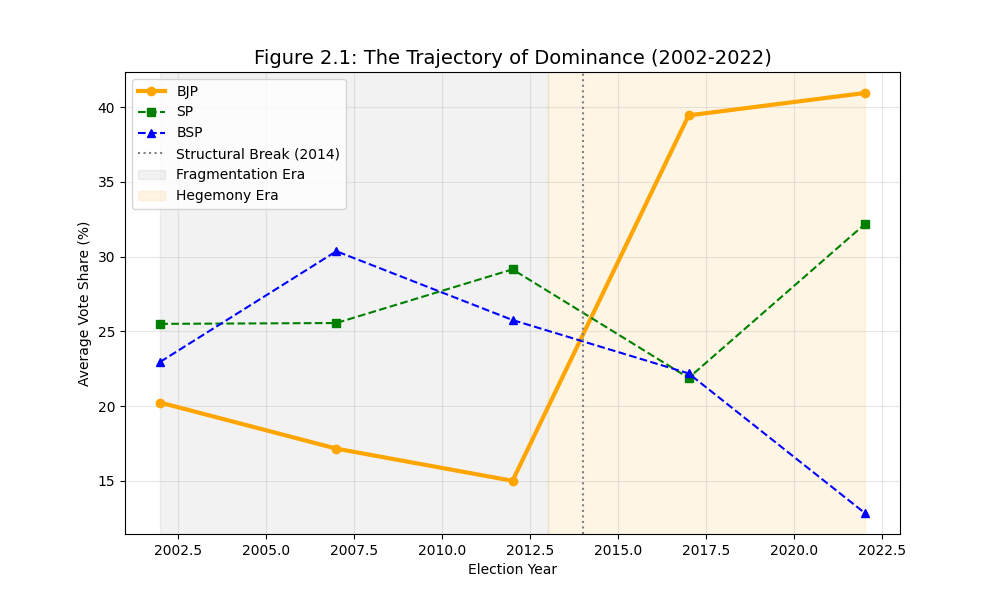

### Figure 6 1 EventStudy


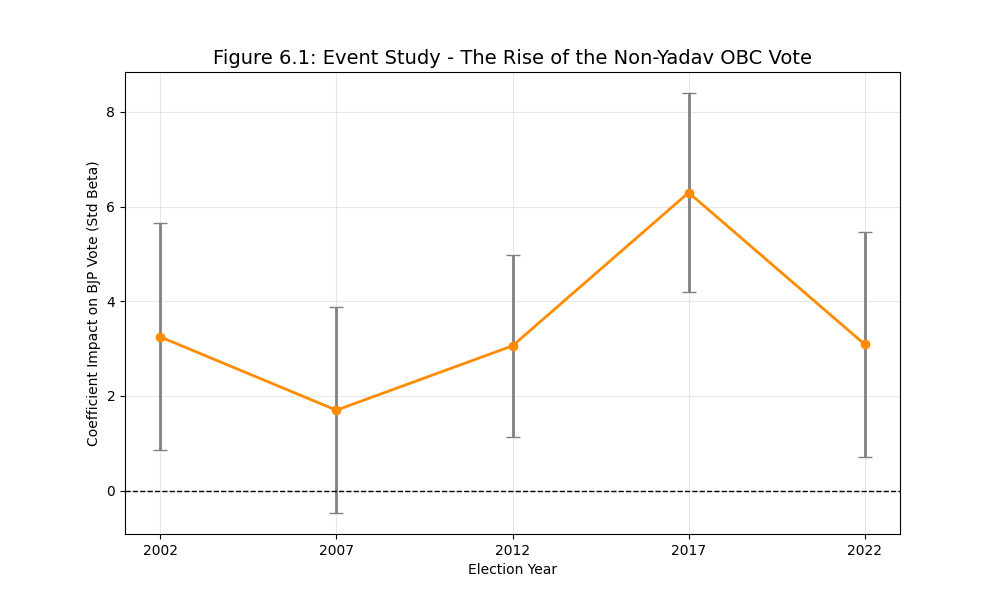

### Figure 6 2 Quantile


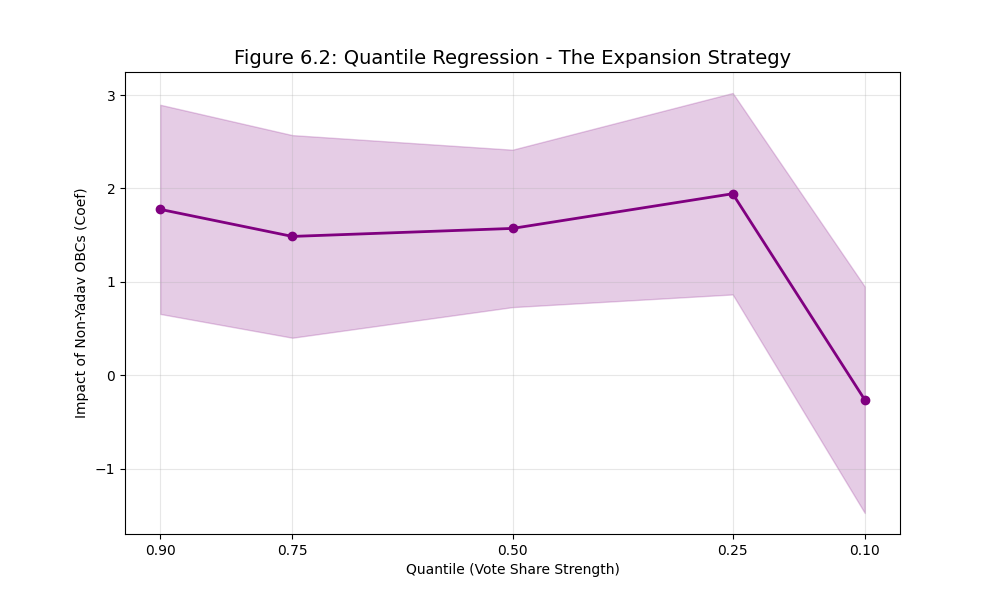

### Figure 6 3 Cannibalization


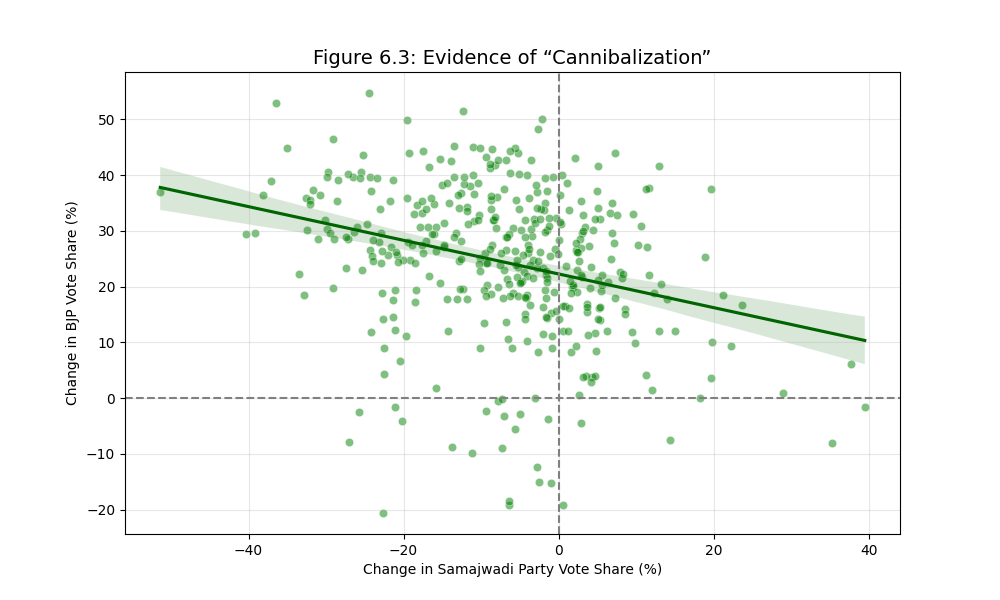

### Figure 6 4 UCurve


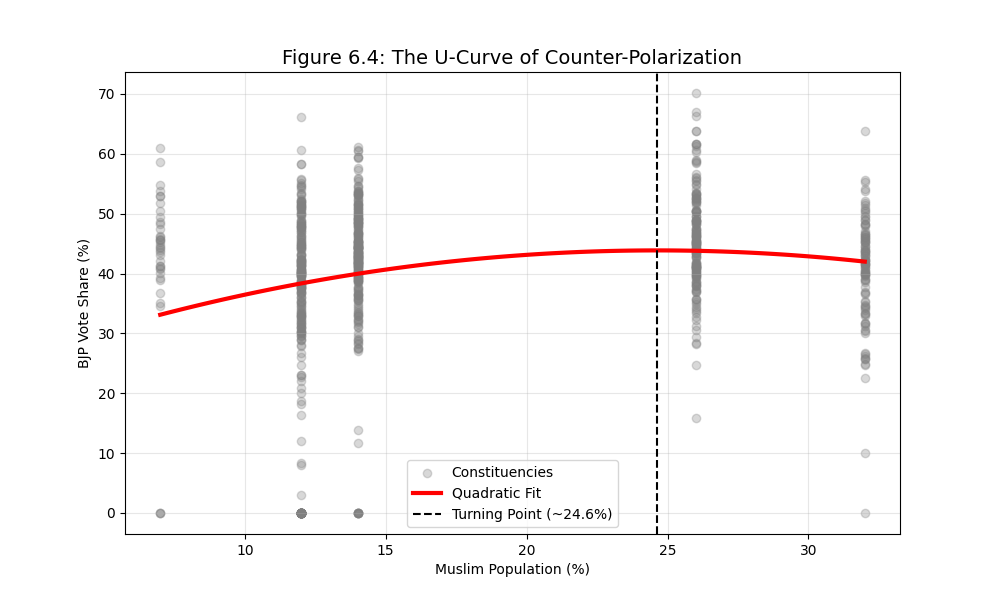

### Figure 6 5 ICC


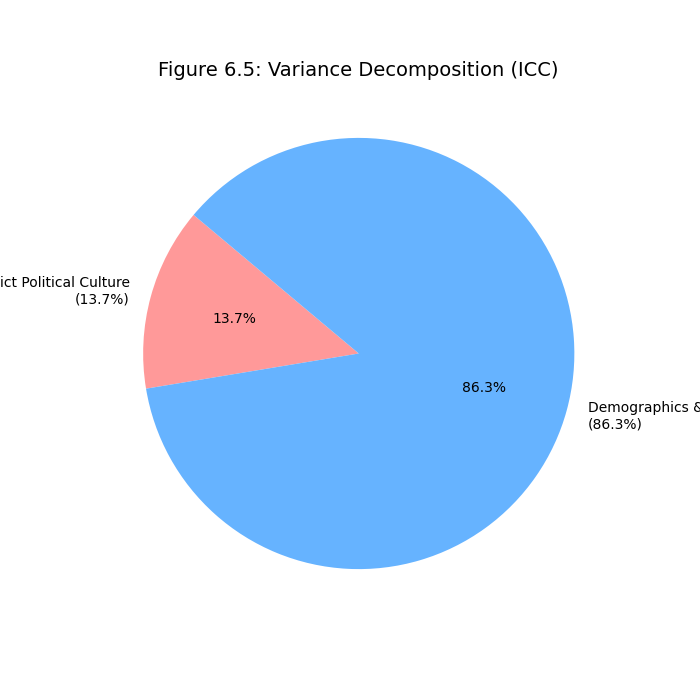

In [ ]:
import os
from IPython.display import Image, display

image_files = [
    'Figure_2_1_Trajectory.png',
    'Figure_6_1_EventStudy.png',
    'Figure_6_2_Quantile.png',
    'Figure_6_3_Cannibalization.png',
    'Figure_6_4_UCurve.png',
    'Figure_6_5_ICC.png'
]

for img_file in image_files:
    print(f"### {img_file.replace('_', ' ').replace('.png', '')}")
    display(Image(filename=img_file, width=600))


In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
import statsmodels.formula.api as smf

# Load the data
df = pd.read_csv('/content/UP_Election_Data_With_Caste_2002_2022.csv')

# --- DATA PREPARATION ---
# 1. Scale vote shares to [0, 1] for Fractional Logit GLM
vote_share_cols = ['BJP_VoteShare', 'SP_VoteShare', 'BSP_VoteShare', 'INC_VoteShare']
df[vote_share_cols] = df[vote_share_cols] / 100

# 2. Create the key structural variable (OBC Non-Yadav Proportion)
# This is needed for the GLM model
df['OBC_NonYadav_Prop'] = df['OBC_NonYadav_Perc'] / 100

# 3. Create the event study dummy (Post-2014)
df['Post_2014'] = np.where(df['Year'] >= 2017, 1, 0)

# Define the common formula structure for the main covariates (using raw percentage for most models)
base_formula = (
    'OBC_NonYadav_Perc + np.power(OBC_NonYadav_Perc, 2) + '
    'UpperCaste_Perc + Dalit_Jatav_Perc + Dalit_NonJatav_Perc + '
    'Muslim_Perc + Turnout + Incumbent + Region + C(Year)'
)

# ----------------------------------------------------------------------------------------------------------------
# --- 1. FRACTIONAL LOGIT GLM (for Bounded Vote Share) ---
# ----------------------------------------------------------------------------------------------------------------
print("--- 1. Fractional Logit GLM ---")
# Dependent variable: BJP_VoteShare (scaled to [0, 1])
# Uses the Binomial family and Logit link, which is the standard Fractional Logit approach.
formula_glm = 'BJP_VoteShare ~ OBC_NonYadav_Prop + np.power(OBC_NonYadav_Prop, 2) + ' + base_formula.replace('OBC_NonYadav_Perc', 'OBC_NonYadav_Prop')
model_glm = smf.glm(formula=formula_glm, data=df, family=families.Binomial())
results_glm = model_glm.fit()
print(results_glm.summary())

print('\n' + '='*80 + '\n')

# ----------------------------------------------------------------------------------------------------------------
# --- 2. QUANTILE REGRESSION (for Heterogeneous Effects) ---
# ----------------------------------------------------------------------------------------------------------------
print("--- 2. Quantile Regression (Q(0.25) and Q(0.75)) ---")
formula_qr = 'BJP_VoteShare ~ ' + base_formula
tau_low = 0.25
tau_high = 0.75

# Quantile 0.25 (Low vote share seats)
model_qr_low = smf.quantreg(formula=formula_qr, data=df, q=tau_low)
results_qr_low = model_qr_low.fit(q=tau_low)
print(f"Quantile {tau_low} Results:")
print(results_qr_low.summary())

# Quantile 0.75 (High vote share seats)
model_qr_high = smf.quantreg(formula=formula_qr, data=df, q=tau_high)
results_qr_high = model_qr_high.fit(q=tau_high)
print(f"\nQuantile {tau_high} Results:")
print(results_qr_high.summary())

print('\n' + '='*80 + '\n')

# ----------------------------------------------------------------------------------------------------------------
# --- 3. HIERARCHICAL LINEAR MODEL (HLM) / Mixed-Effects Model ---
# ----------------------------------------------------------------------------------------------------------------
print("--- 3. Hierarchical Linear Model (HLM) / Mixed-Effects Model ---")
# Accounts for non-independence of observations within the same District_Name (random intercepts).
formula_hlm = (
    'BJP_VoteShare ~ OBC_NonYadav_Perc + np.power(OBC_NonYadav_Perc, 2) + '
    'UpperCaste_Perc + Muslim_Perc + Turnout + Incumbent + C(Year) + Region'
)
model_hlm = smf.mixedlm(formula=formula_hlm, data=df, groups=df['District_Name'])
# Using 'nm' method often helps with convergence for complex models.
results_hlm = model_hlm.fit(method=['nm'])
print(results_hlm.summary())

print('\n' + '='*80 + '\n')

# ----------------------------------------------------------------------------------------------------------------
# --- 4. REGRESSION-BASED EVENT STUDY CHECK (using Interaction Term) ---
# ----------------------------------------------------------------------------------------------------------------
print("--- 4. Regression-Based Event Study Check (using Interaction Term) ---")
# The key test is the interaction term: Post_2014 * OBC_NonYadav_Perc
# This coefficient tests if the structural effect changed significantly after 2014.
formula_es = (
    'BJP_VoteShare ~ Post_2014 * OBC_NonYadav_Perc + '
    'UpperCaste_Perc + Dalit_Jatav_Perc + Dalit_NonJatav_Perc + '
    'Muslim_Perc + Turnout + Incumbent + Region + C(Year)'
)
model_es = smf.ols(formula=formula_es, data=df)
# Using Heteroscedasticity-Consistent (HC3) standard errors for robust estimates.
results_es = model_es.fit(cov_type='HC3')
print(results_es.summary())

--- 1. Fractional Logit GLM ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:          BJP_VoteShare   No. Observations:                 2015
Model:                            GLM   Df Residuals:                     2004
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -769.86
Date:                Mon, 01 Dec 2025   Deviance:                       209.11
Time:                        15:27:46   Pearson chi2:                     170.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.06680
Covariance Type:            nonrobust                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['q']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(eigvals[0]/eigvals[-1])


Quantile 0.25 Results:
                         QuantReg Regression Results                          
Dep. Variable:          BJP_VoteShare   Pseudo R-squared:               0.3060
Model:                       QuantReg   Bandwidth:                     0.03788
Method:                 Least Squares   Sparsity:                       0.3718
Date:                Mon, 01 Dec 2025   No. Observations:                 2015
Time:                        15:27:46   Df Residuals:                     2004
                                        Df Model:                           10
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -0.0002   9.45e-05     -2.357      0.019      -0.000   -3.74e-05
Region[T.Doab/Awadh]               0.0060      0.001      4.693      0.000       0.004       0.009
Region[T.Purvanchal]        

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['q']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(eigvals[0]/eigvals[-1])



Quantile 0.75 Results:
                         QuantReg Regression Results                          
Dep. Variable:          BJP_VoteShare   Pseudo R-squared:               0.3430
Model:                       QuantReg   Bandwidth:                     0.03752
Method:                 Least Squares   Sparsity:                       0.3085
Date:                Mon, 01 Dec 2025   No. Observations:                 2015
Time:                        15:27:47   Df Residuals:                     2004
                                        Df Model:                           10
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.0004    7.9e-05      5.401      0.000       0.000       0.001
Region[T.Doab/Awadh]               0.0011      0.001      0.990      0.322      -0.001       0.003
Region[T.Purvanchal]       

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2704: RuntimeWarning: invalid value encountered in sqrt
  sdf[0:self.k_fe, 1] = np.sqrt(np.diag(self.cov_params()[0:self.k_fe]))


                       Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         BJP_VoteShare
No. Observations:          2015            Method:                     REML         
No. Groups:                77              Scale:                      0.0137       
Min. group size:           5               Log-Likelihood:             1418.6322    
Max. group size:           60              Converged:                  Yes          
Mean group size:           26.2                                                     
------------------------------------------------------------------------------------
                               Coef.   Std.Err.    z    P>|z|    [0.025     0.975]  
------------------------------------------------------------------------------------
Intercept                      -0.838 507376.784 -0.000 1.000 -994441.062 994439.386
C(Year)[T.2007]                -0.060      0.009 -6.616 0.000      -0.078     -0.042
C(Ye

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 12
  warnings.warn('covariance of constraints does not have full '


### Fractional Logit GLM Results (LaTeX)

In [3]:
print(results_glm.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}                   &  BJP\_VoteShare  & \textbf{  No. Observations:  } &     2015    \\
\textbf{Model:}                           &       GLM        & \textbf{  Df Residuals:      } &     2004    \\
\textbf{Model Family:}                    &     Binomial     & \textbf{  Df Model:          } &       10    \\
\textbf{Link Function:}                   &      Logit       & \textbf{  Scale:             } &    1.0000   \\
\textbf{Method:}                          &       IRLS       & \textbf{  Log-Likelihood:    } &   -769.86   \\
\textbf{Date:}                            & Mon, 01 Dec 2025 & \textbf{  Deviance:          } &    209.11   \\
\textbf{Time:}                            &     15:28:50     & \textbf{  Pearson chi2:      } &     170.    \\
\textbf{No. Iterations:}                  &        5         & \textbf{  Pseudo R-squ. (CS):} &  0.06680    \\
\textbf{Covariance Type:}                 &    nonrobust     & \te

### Quantile Regression Q(0.25) Results (LaTeX)

In [4]:
print(results_qr_low.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}                   &  BJP\_VoteShare  & \textbf{  Pseudo R-squared:  } &    0.3060   \\
\textbf{Model:}                           &     QuantReg     & \textbf{  Bandwidth:         } &   0.03788   \\
\textbf{Method:}                          &  Least Squares   & \textbf{  Sparsity:          } &    0.3718   \\
\textbf{Date:}                            & Mon, 01 Dec 2025 & \textbf{  No. Observations:  } &     2015    \\
\textbf{Time:}                            &     15:28:51     & \textbf{  Df Residuals:      } &     2004    \\
\textbf{ }                                &                  & \textbf{  Df Model:          } &       10    \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                                          & \textbf{coef} & \textbf{std err} & \textbf{t} & \textbf{P$> |$t$|$} & \textbf{[0.025} & \textbf{0.975]}  \\
\midrule
\textbf{Intercept}                        &      -0.0002  &     9.45e-05    

### Quantile Regression Q(0.75) Results (LaTeX)

In [5]:
print(results_qr_high.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}                   &  BJP\_VoteShare  & \textbf{  Pseudo R-squared:  } &    0.3430   \\
\textbf{Model:}                           &     QuantReg     & \textbf{  Bandwidth:         } &   0.03752   \\
\textbf{Method:}                          &  Least Squares   & \textbf{  Sparsity:          } &    0.3085   \\
\textbf{Date:}                            & Mon, 01 Dec 2025 & \textbf{  No. Observations:  } &     2015    \\
\textbf{Time:}                            &     15:28:52     & \textbf{  Df Residuals:      } &     2004    \\
\textbf{ }                                &                  & \textbf{  Df Model:          } &       10    \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                                          & \textbf{coef} & \textbf{std err} & \textbf{t} & \textbf{P$> |$t$|$} & \textbf{[0.025} & \textbf{0.975]}  \\
\midrule
\textbf{Intercept}                        &       0.0004  &      7.9e-05    

### Hierarchical Linear Model (HLM) Results (LaTeX)

In [6]:
print(results_hlm.summary().as_latex())

\begin{table}
\caption{Mixed Linear Model Regression Results}
\label{}
\begin{center}
\begin{tabular}{llll}
\hline
Model:            & MixedLM & Dependent Variable: & BJP\_VoteShare  \\
No. Observations: & 2015    & Method:             & REML            \\
No. Groups:       & 77      & Scale:              & 0.0137          \\
Min. group size:  & 5       & Log-Likelihood:     & 1418.6322       \\
Max. group size:  & 60      & Converged:          & Yes             \\
Mean group size:  & 26.2    &                     &                 \\
\hline
\end{tabular}
\end{center}

\begin{center}
\begin{tabular}{lrrrrrr}
\hline
                                 &  Coef. &   Std.Err. &      z & P$> |$z$|$ &      [0.025 &     0.975]  \\
\hline
Intercept                        & -0.838 & 507376.784 & -0.000 &       1.000 & -994441.062 & 994439.386  \\
C(Year)[T.2007]                  & -0.060 &      0.009 & -6.616 &       0.000 &      -0.078 &     -0.042  \\
C(Year)[T.2012]                  & -0.033 & 

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2704: RuntimeWarning: invalid value encountered in sqrt
  sdf[0:self.k_fe, 1] = np.sqrt(np.diag(self.cov_params()[0:self.k_fe]))


### Regression-Based Event Study Results (LaTeX)

In [7]:
print(results_es.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}                 &  BJP\_VoteShare  & \textbf{  R-squared:         } &     0.482   \\
\textbf{Model:}                         &       OLS        & \textbf{  Adj. R-squared:    } &     0.479   \\
\textbf{Method:}                        &  Least Squares   & \textbf{  F-statistic:       } &     1099.   \\
\textbf{Date:}                          & Mon, 01 Dec 2025 & \textbf{  Prob (F-statistic):} &     0.00    \\
\textbf{Time:}                          &     15:28:53     & \textbf{  Log-Likelihood:    } &    1401.2   \\
\textbf{No. Observations:}              &        2015      & \textbf{  AIC:               } &    -2778.   \\
\textbf{Df Residuals:}                  &        2003      & \textbf{  BIC:               } &    -2711.   \\
\textbf{Df Model:}                      &          11      & \textbf{                     } &             \\
\textbf{Covariance Type:}               &       HC3        & \textbf{             